# Process Ausgrid Solar Home Dataset (ASHD) 148-Household Sydney Airport Dataset

## Purpose
This notebook creates ASHD variants that match the Australia Energy Data Platform (AEDP) Cluster 2 household count (`148 households`). The households are selected from the original 300 Ausgrid Solar Home Dataset (ASHD) customers by postcode-centroid distance to Sydney Airport Australian Bureau of Meteorology (BOM) station.

Outputs:

- `data/ds19_ashd_148hh.csv`
- `data/ds20_ashd_148hh_with_weather.csv`
- `data/ds21_ashd_148hh_with_weather_cloud_solcast.csv`
- `selected_ashd_148hh_sydney_airport.csv` beside this notebook for auditability

## Inputs
- `RAW_ASHD_FILES[0]`
- `POSTCODE_LOOKUP_FILE`
- `DATA_DIR / "ds1_ashd.csv"`
- `BOM_WEATHER_FILE`
- `SOLCAST_CLOUD_FILE`

## Run Flow
1. Setup
2. Select the 148 nearest ASHD households
3. Visualise the selected households
4. Aggregate ASHD net load
5. Export `ds19`: ASHD 148 households without weather
6. Add Sydney Airport BOM weather for `ds20`
7. Add Solcast cloud opacity for `ds21`
8. Final validation

## Outputs
- `AUDIT_PATH`
- `DS19_PATH`
- `DS20_PATH`
- `DS21_PATH`

## 1. Setup

Define the raw-data locations, Sydney Airport coordinates, output files, and expected ASHD date range. The path resolver lets the notebook run either from the repository root or from this notebook folder.

In [1]:
import os
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.testing import assert_index_equal


def find_repo_root(start=None):
    """Find the PyNNLF repository root from the current working directory."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the PyNNLF repository root.")


REPO_ROOT = find_repo_root()
NOTEBOOK_DIR = REPO_ROOT / "ignored_from_git" / "notebook_process_data" / "Process ASHD data"
DATA_DIR = REPO_ROOT / "data"

def raw_data_root():
    """Locate the local source data tree, which is not distributed with this repository.

    Set the PYNNLF_RAW_DATA_DIR environment variable to the directory holding the
    "1. raw", "2. processed" and "3. cleaned" folders before running this notebook.

    Returns:
        Path: root of the local source data tree.
    """
    root = os.environ.get("PYNNLF_RAW_DATA_DIR")
    if not root:
        raise RuntimeError(
            "PYNNLF_RAW_DATA_DIR is not set. Point it at your local source data "
            "directory; see the Data section of the repository README."
        )
    return Path(root)


RAW_DATA_ROOT = raw_data_root()

RAW_ASHD_DIR = RAW_DATA_ROOT / "1. raw" / "Solar Home Electricity Data"
RAW_ASHD_FILES = [
    RAW_ASHD_DIR / "2010-2011 Solar home electricity data.csv",
    RAW_ASHD_DIR / "2011-2012 Solar home electricity data v2.csv",
    RAW_ASHD_DIR / "2012-2013 Solar home electricity data v2.csv",
]

POSTCODE_LOOKUP_FILE = RAW_DATA_ROOT / "1. raw" / "ACAP EDP" / "Metadata" / "postcode data" / "AU.txt"
BOM_WEATHER_FILE = RAW_DATA_ROOT / "1. raw" / "BOM Weather Data" / "bom_data_nsw55167608.csv"
SOLCAST_CLOUD_FILE = RAW_ASHD_DIR / "Cloud Data from Solcast" / "csv_-33.950033_151.181695_fixed_23_0_PT30M.csv"

START = pd.Timestamp("2010-07-01 00:00:00")
END = pd.Timestamp("2013-06-30 23:30:00")
EXPECTED_INDEX = pd.date_range(START, END, freq="30min", name="datetime")
EXPECTED_ROWS = len(EXPECTED_INDEX)

SYDNEY_AIRPORT_LAT = -33.950033
SYDNEY_AIRPORT_LON = 151.181695
SYDNEY_AIRPORT_BOM_STATION = 66037

DS19_PATH = DATA_DIR / "ds19_ashd_148hh.csv"
DS20_PATH = DATA_DIR / "ds20_ashd_148hh_with_weather.csv"
DS21_PATH = DATA_DIR / "ds21_ashd_148hh_with_weather_cloud_solcast.csv"
AUDIT_PATH = NOTEBOOK_DIR / "selected_ashd_148hh_sydney_airport.csv"

for path in [*RAW_ASHD_FILES, POSTCODE_LOOKUP_FILE, BOM_WEATHER_FILE, SOLCAST_CLOUD_FILE]:
    if not path.exists():
        raise FileNotFoundError(path)

print(f"Repository root: {REPO_ROOT}")
print(f"Expected half-hour rows: {EXPECTED_ROWS:,}")


Repository root: <local path redacted>
Expected half-hour rows: 52,608


## 2. Select the 148 nearest ASHD households

ASHD does not include household latitude/longitude. It includes `Postcode`, so the nearest-household selection uses postcode centroids from `AU.txt`. Customers are ranked by haversine distance to Sydney Airport, with `Customer` ID as the deterministic tie-breaker.

In [2]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised haversine distance in kilometres."""
    earth_radius_km = 6371.0088
    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)
    dlat = lat1 - lat2
    dlon = lon1 - lon2
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * math.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))


# Customer-postcode mapping is stable across all three ASHD annual files.
customer_locations = pd.read_csv(
    RAW_ASHD_FILES[0],
    header=1,
    usecols=["Customer", "Postcode"],
).drop_duplicates()
customer_locations["Customer"] = customer_locations["Customer"].astype(int)
customer_locations["Postcode"] = customer_locations["Postcode"].astype(int)

postcode_lookup = pd.read_csv(
    POSTCODE_LOOKUP_FILE,
    sep="\t",
    header=None,
    usecols=[1, 9, 10],
    names=["Postcode", "postcode_lat", "postcode_lon"],
)
postcode_lookup = postcode_lookup.drop_duplicates(subset="Postcode", keep="first")
postcode_lookup["Postcode"] = postcode_lookup["Postcode"].astype(int)

households = customer_locations.merge(postcode_lookup, on="Postcode", how="left", validate="many_to_one")
if households[["postcode_lat", "postcode_lon"]].isna().any().any():
    missing = households.loc[households[["postcode_lat", "postcode_lon"]].isna().any(axis=1), "Postcode"].unique()
    raise ValueError(f"Missing postcode coordinates for: {missing}")

households["distance_km"] = haversine_km(
    households["postcode_lat"],
    households["postcode_lon"],
    SYDNEY_AIRPORT_LAT,
    SYDNEY_AIRPORT_LON,
)

households = households.sort_values(["distance_km", "Customer"], kind="mergesort").reset_index(drop=True)
households["selection_rank"] = np.arange(1, len(households) + 1)
selected_households = households.head(148).copy()
selected_customers = set(selected_households["Customer"])
selection_radius_km = float(selected_households["distance_km"].max())

if len(selected_households) != 148:
    raise AssertionError("Expected exactly 148 selected households.")

selected_households.to_csv(AUDIT_PATH, index=False)

print(f"All ASHD households: {len(households)}")
print(f"Selected households: {len(selected_households)}")
print(f"Selected postcode count: {selected_households['Postcode'].nunique()}")
print(f"Selection radius: {selection_radius_km:.3f} km")
print(f"Audit file: {AUDIT_PATH}")
display(selected_households.head(10))
display(selected_households.tail(10))


All ASHD households: 300
Selected households: 148
Selected postcode count: 64
Selection radius: 38.123 km
Audit file: <local path redacted>


,Customer,Postcode,postcode_lat,postcode_lon,distance_km,selection_rank
0,298,2216,-33.9535,151.1481,3.122598,1
1,43,2205,-33.9313,151.1522,3.426691,2
2,193,2205,-33.9313,151.1522,3.426691,3
3,229,2205,-33.9313,151.1522,3.426691,4
4,128,2044,-33.9233,151.1602,3.573300,5
5,164,2044,-33.9233,151.1602,3.573300,6
6,288,2044,-33.9233,151.1602,3.573300,7
7,139,2018,-33.9167,151.2000,4.073060,8
8,192,2018,-33.9167,151.2000,4.073060,9
9,71,2204,-33.9074,151.1555,5.321096,10


,Customer,Postcode,postcode_lat,postcode_lon,distance_km,selection_rank
138,241,2077,-33.7024,151.0993,28.568094,139
139,247,2077,-33.7024,151.0993,28.568094,140
140,250,2154,-33.7333,151.0000,29.366368,141
141,123,2079,-33.6833,151.1167,30.261084,142
142,195,2079,-33.6833,151.1167,30.261084,143
143,210,2079,-33.6833,151.1167,30.261084,144
144,274,2084,-33.6583,151.2107,32.549789,145
145,102,2081,-33.6208,151.1509,36.719546,146
146,114,2159,-33.6155,151.0914,38.122990,147
147,243,2159,-33.6155,151.0914,38.122990,148


## 3. Visualise the selected households

The plots show all 300 ASHD customers by postcode centroid, the 148 selected customers, Sydney Airport, and the distance radius of the farthest selected customer.

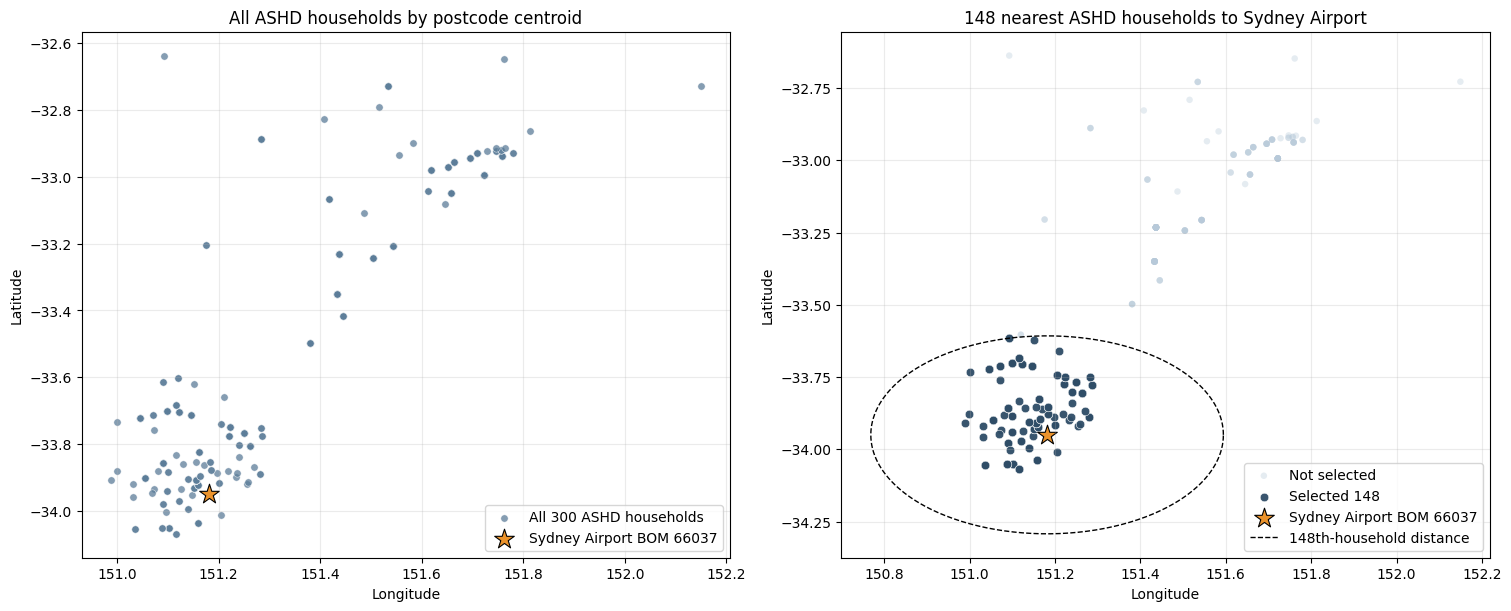

In [3]:
def add_selection_radius(ax, radius_km):
    """Draw an approximate lat/lon radius around Sydney Airport for visual context."""
    theta = np.linspace(0, 2 * np.pi, 361)
    lat_radius = radius_km / 111.32
    lon_radius = radius_km / (111.32 * math.cos(math.radians(SYDNEY_AIRPORT_LAT)))
    ax.plot(
        SYDNEY_AIRPORT_LON + lon_radius * np.cos(theta),
        SYDNEY_AIRPORT_LAT + lat_radius * np.sin(theta),
        color="black",
        linestyle="--",
        linewidth=1,
        label="148th-household distance",
    )


fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

axes[0].scatter(
    households["postcode_lon"],
    households["postcode_lat"],
    s=28,
    alpha=0.75,
    color="#5C7D99",
    edgecolor="white",
    linewidth=0.4,
    label="All 300 ASHD households",
)
axes[0].scatter(
    SYDNEY_AIRPORT_LON,
    SYDNEY_AIRPORT_LAT,
    marker="*",
    s=220,
    color="#EB932C",
    edgecolor="black",
    linewidth=0.8,
    label="Sydney Airport BOM 66037",
)
axes[0].set_title("All ASHD households by postcode centroid")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.25)

axes[1].scatter(
    households["postcode_lon"],
    households["postcode_lat"],
    s=22,
    alpha=0.35,
    color="#B7C9D9",
    edgecolor="none",
    label="Not selected",
)
axes[1].scatter(
    selected_households["postcode_lon"],
    selected_households["postcode_lat"],
    s=38,
    alpha=0.95,
    color="#2F4D67",
    edgecolor="white",
    linewidth=0.4,
    label="Selected 148",
)
axes[1].scatter(
    SYDNEY_AIRPORT_LON,
    SYDNEY_AIRPORT_LAT,
    marker="*",
    s=220,
    color="#EB932C",
    edgecolor="black",
    linewidth=0.8,
    label="Sydney Airport BOM 66037",
)
add_selection_radius(axes[1], selection_radius_km)
axes[1].set_title("148 nearest ASHD households to Sydney Airport")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.25)

plt.show()


## 4. Aggregate ASHD net load

This section reproduces the existing ASHD aggregation method before applying it to the selected 148 households:

- use only `GC` and `GG`,
- ignore controlled load `CL`,
- calculate `netload_kWh = GC - GG`,
- convert half-hour energy to average power with `netload_kW = netload_kWh * 2`.


In [4]:
TIME_COLUMN_PATTERN = re.compile(r"^\d{1,2}:\d{2}$")


def parse_ashd_datetime(date_series, time_series):
    """Parse ASHD date strings plus half-hour column labels into timestamps."""
    dates = pd.to_datetime(date_series, dayfirst=True, errors="raise")
    parts = time_series.str.split(":", expand=True).astype(int)
    return dates + pd.to_timedelta(parts[0], unit="h") + pd.to_timedelta(parts[1], unit="m")


def aggregate_ashd(customers=None):
    """Aggregate raw ASHD annual files to a half-hourly net-load time series."""
    frames = []
    customers = None if customers is None else set(int(customer) for customer in customers)

    for raw_file in RAW_ASHD_FILES:
        header = pd.read_csv(raw_file, header=1, nrows=0)
        time_columns = [col for col in header.columns if TIME_COLUMN_PATTERN.match(str(col))]
        usecols = ["Customer", "Consumption Category", "date", *time_columns]

        raw = pd.read_csv(raw_file, header=1, usecols=usecols)
        raw["Customer"] = raw["Customer"].astype(int)
        raw = raw[raw["Consumption Category"].isin(["GC", "GG"])]
        if customers is not None:
            raw = raw[raw["Customer"].isin(customers)]

        long = raw.melt(
            id_vars=["Customer", "Consumption Category", "date"],
            value_vars=time_columns,
            var_name="time",
            value_name="kWh",
        )
        long["datetime"] = parse_ashd_datetime(long["date"], long["time"])
        frames.append(long[["datetime", "Consumption Category", "kWh"]])

    long_all = pd.concat(frames, ignore_index=True)
    category_totals = (
        long_all
        .groupby(["datetime", "Consumption Category"], observed=True)["kWh"]
        .sum()
        .unstack("Consumption Category")
        .sort_index()
    )

    for required_column in ["GC", "GG"]:
        if required_column not in category_totals.columns:
            raise ValueError(f"Missing required ASHD category: {required_column}")

    result = pd.DataFrame(index=category_totals.index)
    result.index.name = "datetime"
    result["grossload_kWh"] = category_totals["GC"]
    result["pv_kWh"] = category_totals["GG"]
    result["netload_kWh"] = result["grossload_kWh"] - result["pv_kWh"]
    result["netload_kW"] = result["netload_kWh"] * 2
    result = result.loc[EXPECTED_INDEX]
    return result.reset_index()


# Validate the aggregation by reproducing the existing 300-household ds1 exactly enough for floating point arithmetic.
recreated_ds1 = aggregate_ashd()
existing_ds1 = pd.read_csv(DATA_DIR / "ds1_ashd.csv", parse_dates=["datetime"])

assert recreated_ds1[["datetime", "netload_kW"]].shape == existing_ds1.shape
assert_index_equal(
    pd.Index(recreated_ds1["datetime"]),
    pd.Index(existing_ds1["datetime"]),
    check_names=False,
)
max_abs_diff = (recreated_ds1["netload_kW"] - existing_ds1["netload_kW"]).abs().max()
if max_abs_diff > 1e-9:
    raise AssertionError(f"Recreated ds1 differs from existing ds1, max abs diff = {max_abs_diff}")

print(f"Recreated existing ds1 successfully; max abs diff = {max_abs_diff:.3g} kW")


<local path redacted>
  dates = pd.to_datetime(date_series, dayfirst=True, errors="raise")


Recreated existing ds1 successfully; max abs diff = 5.68e-14 kW


## 5. Export `ds19`: ASHD 148 households without weather

`ds19` keeps only the target required by PyNNLF: `datetime` and `netload_kW`.

In [5]:
ashd_148_full = aggregate_ashd(selected_customers)
ds19 = ashd_148_full[["datetime", "netload_kW"]].copy()
ds19.to_csv(DS19_PATH, index=False)

print(f"Exported {DS19_PATH.name}: {ds19.shape[0]:,} rows")
display(ds19.head())
display(ds19.tail())


<local path redacted>
  dates = pd.to_datetime(date_series, dayfirst=True, errors="raise")


Exported ds19_ashd_148hh.csv: 52,608 rows


,datetime,netload_kW
0,2010-07-01 00:00:00,106.446
1,2010-07-01 00:30:00,107.454
2,2010-07-01 01:00:00,97.336
3,2010-07-01 01:30:00,89.238
4,2010-07-01 02:00:00,81.964


,datetime,netload_kW
52603,2013-06-30 21:30:00,169.248
52604,2013-06-30 22:00:00,169.740
52605,2013-06-30 22:30:00,155.120
52606,2013-06-30 23:00:00,147.436
52607,2013-06-30 23:30:00,119.152


## 6. Add Sydney Airport BOM weather for `ds20`

Use the same weather variables as AEDP `ds11` from Sydney Airport BOM station `66037`:

- `air_temperature_in_degrees_c`
- `relative_humidity_in_percentage`
- `wind_speed_in_km_h`

The station number is used only for filtering and is not exported as a model feature.

In [6]:
WEATHER_COLUMNS = [
    "air_temperature_in_degrees_c",
    "relative_humidity_in_percentage",
    "wind_speed_in_km_h",
]


def load_sydney_airport_weather():
    """Load and align Sydney Airport BOM weather to the ASHD half-hourly index."""
    usecols = ["station_number", "datetime", *WEATHER_COLUMNS]
    chunks = []
    for chunk in pd.read_csv(BOM_WEATHER_FILE, usecols=usecols, chunksize=100_000):
        chunk = chunk[chunk["station_number"] == SYDNEY_AIRPORT_BOM_STATION]
        if not chunk.empty:
            chunks.append(chunk)

    if not chunks:
        raise ValueError(f"No BOM rows found for station {SYDNEY_AIRPORT_BOM_STATION}")

    weather = pd.concat(chunks, ignore_index=True)
    weather["datetime"] = pd.to_datetime(weather["datetime"], errors="raise")
    weather = weather[(weather["datetime"] >= START) & (weather["datetime"] <= END)]
    weather = weather.sort_values("datetime").drop_duplicates(subset="datetime", keep="first")

    expected = pd.DataFrame({"datetime": EXPECTED_INDEX})
    weather = expected.merge(weather, on="datetime", how="left")
    weather[WEATHER_COLUMNS] = weather[WEATHER_COLUMNS].ffill()

    if weather[WEATHER_COLUMNS].isna().any().any():
        missing_counts = weather[WEATHER_COLUMNS].isna().sum()
        raise ValueError(f"Weather data still contains missing values after forward fill:\n{missing_counts}")

    return weather[["datetime", *WEATHER_COLUMNS]]


weather = load_sydney_airport_weather()
ds20 = ds19.merge(weather, on="datetime", how="left", validate="one_to_one")
ds20 = ds20[["datetime", "netload_kW", *WEATHER_COLUMNS]]
if "station_number" in ds20.columns:
    raise AssertionError("station_number must not be exported in ds20")

ds20.to_csv(DS20_PATH, index=False)

print(f"Exported {DS20_PATH.name}: {ds20.shape[0]:,} rows")
display(ds20.head())


Exported ds20_ashd_148hh_with_weather.csv: 52,608 rows


,datetime,netload_kW,air_temperature_in_degrees_c,relative_humidity_in_percentage,wind_speed_in_km_h
0,2010-07-01 00:00:00,106.446,8.4,66.0,13.0
1,2010-07-01 00:30:00,107.454,7.9,67.0,13.0
2,2010-07-01 01:00:00,97.336,7.5,68.0,16.6
3,2010-07-01 01:30:00,89.238,7.4,69.0,18.4
4,2010-07-01 02:00:00,81.964,7.2,68.0,20.5


## 7. Add Solcast cloud opacity for `ds21`

Use the available Sydney Airport Solcast 30-minute file for 2010-2013 and keep only `cloud_opacity`. Solcast documents this as a 0-100 measure, where 0 means no cloud and 100 means completely cloudy.

In [7]:
def load_solcast_cloud_opacity():
    """Load Sydney Airport Solcast cloud opacity and align it to the ASHD half-hourly index."""
    solcast = pd.read_csv(SOLCAST_CLOUD_FILE, usecols=["period_end", "cloud_opacity"])
    solcast_datetime = pd.to_datetime(solcast["period_end"], errors="raise")

    # The source timestamp is timezone-aware local Sydney time. Match the older notebook by removing the timezone
    # without converting to UTC, so 2010-07-01 00:00 stays aligned to ASHD local timestamps.
    if solcast_datetime.dt.tz is not None:
        solcast_datetime = solcast_datetime.dt.tz_localize(None)

    solcast = pd.DataFrame({
        "datetime": solcast_datetime,
        "cloud_opacity": solcast["cloud_opacity"],
    })
    solcast = solcast.sort_values("datetime").drop_duplicates(subset="datetime", keep="first")

    expected = pd.DataFrame({"datetime": EXPECTED_INDEX})
    cloud = expected.merge(solcast, on="datetime", how="left")
    if cloud["cloud_opacity"].isna().any():
        missing = int(cloud["cloud_opacity"].isna().sum())
        raise ValueError(f"Solcast cloud_opacity is missing for {missing:,} ASHD timestamps")

    return cloud


cloud = load_solcast_cloud_opacity()
ds21 = ds20.merge(cloud, on="datetime", how="left", validate="one_to_one")
ds21 = ds21[["datetime", "netload_kW", *WEATHER_COLUMNS, "cloud_opacity"]]
ds21.to_csv(DS21_PATH, index=False)

print(f"Exported {DS21_PATH.name}: {ds21.shape[0]:,} rows")
display(ds21.head())


Exported ds21_ashd_148hh_with_weather_cloud_solcast.csv: 52,608 rows


,datetime,netload_kW,air_temperature_in_degrees_c,relative_humidity_in_percentage,wind_speed_in_km_h,cloud_opacity
0,2010-07-01 00:00:00,106.446,8.4,66.0,13.0,0.0
1,2010-07-01 00:30:00,107.454,7.9,67.0,13.0,0.0
2,2010-07-01 01:00:00,97.336,7.5,68.0,16.6,0.0
3,2010-07-01 01:30:00,89.238,7.4,69.0,18.4,0.0
4,2010-07-01 02:00:00,81.964,7.2,68.0,20.5,0.0


## 8. Final validation

Confirm row counts, timestamp regularity, missing values, column order, and export paths for all generated datasets.

In [8]:
expected_columns = {
    DS19_PATH.name: ["datetime", "netload_kW"],
    DS20_PATH.name: ["datetime", "netload_kW", *WEATHER_COLUMNS],
    DS21_PATH.name: ["datetime", "netload_kW", *WEATHER_COLUMNS, "cloud_opacity"],
}

validation_rows = []
for path in [DS19_PATH, DS20_PATH, DS21_PATH]:
    dataset = pd.read_csv(path, parse_dates=["datetime"])
    if list(dataset.columns) != expected_columns[path.name]:
        raise AssertionError(f"Unexpected columns in {path.name}: {list(dataset.columns)}")
    if dataset.shape[0] != EXPECTED_ROWS:
        raise AssertionError(f"{path.name} expected {EXPECTED_ROWS:,} rows, found {dataset.shape[0]:,}")
    if dataset["datetime"].duplicated().any():
        raise AssertionError(f"{path.name} contains duplicate timestamps")
    if dataset.isna().any().any():
        raise AssertionError(f"{path.name} contains missing values")
    if dataset["datetime"].min() != START or dataset["datetime"].max() != END:
        raise AssertionError(f"{path.name} has an unexpected date range")

    freq_minutes = dataset["datetime"].diff().dropna().dt.total_seconds().unique() / 60
    if len(freq_minutes) != 1 or freq_minutes[0] != 30:
        raise AssertionError(f"{path.name} does not have regular 30-minute spacing")

    validation_rows.append({
        "dataset": path.name,
        "rows": dataset.shape[0],
        "columns": ", ".join(dataset.columns),
        "start": dataset["datetime"].min(),
        "end": dataset["datetime"].max(),
        "missing_values": int(dataset.isna().sum().sum()),
    })

validation = pd.DataFrame(validation_rows)
display(validation)
print("All ASHD 148-household dataset exports passed validation.")


,dataset,rows,columns,start,end,missing_values
0,ds19_ashd_148hh.csv,52608,"datetime, netload_kW",2010-07-01,2013-06-30 23:30:00,0
1,ds20_ashd_148hh_with_weather.csv,52608,"datetime, netload_kW, air_temperature_in_degre...",2010-07-01,2013-06-30 23:30:00,0
2,ds21_ashd_148hh_with_weather_cloud_solcast.csv,52608,"datetime, netload_kW, air_temperature_in_degre...",2010-07-01,2013-06-30 23:30:00,0


All ASHD 148-household dataset exports passed validation.
